In [13]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.style as style
style.use('~/styles/clarke-default.mplstyle')
import tensorflow as tf
from tensorflow import keras
from scipy.interpolate import griddata

2025-03-19 18:36:03.040310: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-19 18:36:04.106656: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [61]:
pmts = False
sensors = 'PMTs' if pmts else 'SiPMs'
save_figures = False
pmt_qe = 0.3

In [62]:
mc_truth_pos = []
detected = []
pte = []

with h5py.File('chroma-lxe/s2_sim_test2_' + sensors + '_ss.h5', 'r') as f:
    print(f.keys())
    for key in f.keys():
        if '_detected' in key:
            detected.append(f[key][()])
        elif 'posX' in key:
            mc_truth_pos.append(f[key][()])
        elif 'posY' in key:
            mc_truth_pos.append(f[key][()])
        elif 'posZ' in key:
            mc_truth_pos.append(f[key][()])
        elif key=='pte':
            pte.append(f[key][()])

ss_mc_truth_pos = np.array(mc_truth_pos).swapaxes(0, 1)
ss_n_detected = np.random.binomial(np.array(detected).swapaxes(0, 1).astype(int), pmt_qe)
ss_pte = np.array(pte)[0]

<KeysViewHDF5 ['ch0_detected', 'ch0_pte', 'ch1_detected', 'ch1_pte', 'ch2_detected', 'ch2_pte', 'ch3_detected', 'ch3_pte', 'ch4_detected', 'ch4_pte', 'ch5_detected', 'ch5_pte', 'ch6_detected', 'ch6_pte', 'ch7_detected', 'ch7_pte', 'ch8_detected', 'ch8_pte', 'detected', 'n', 'posX', 'posY', 'posZ', 'pte', 'time_spent']>


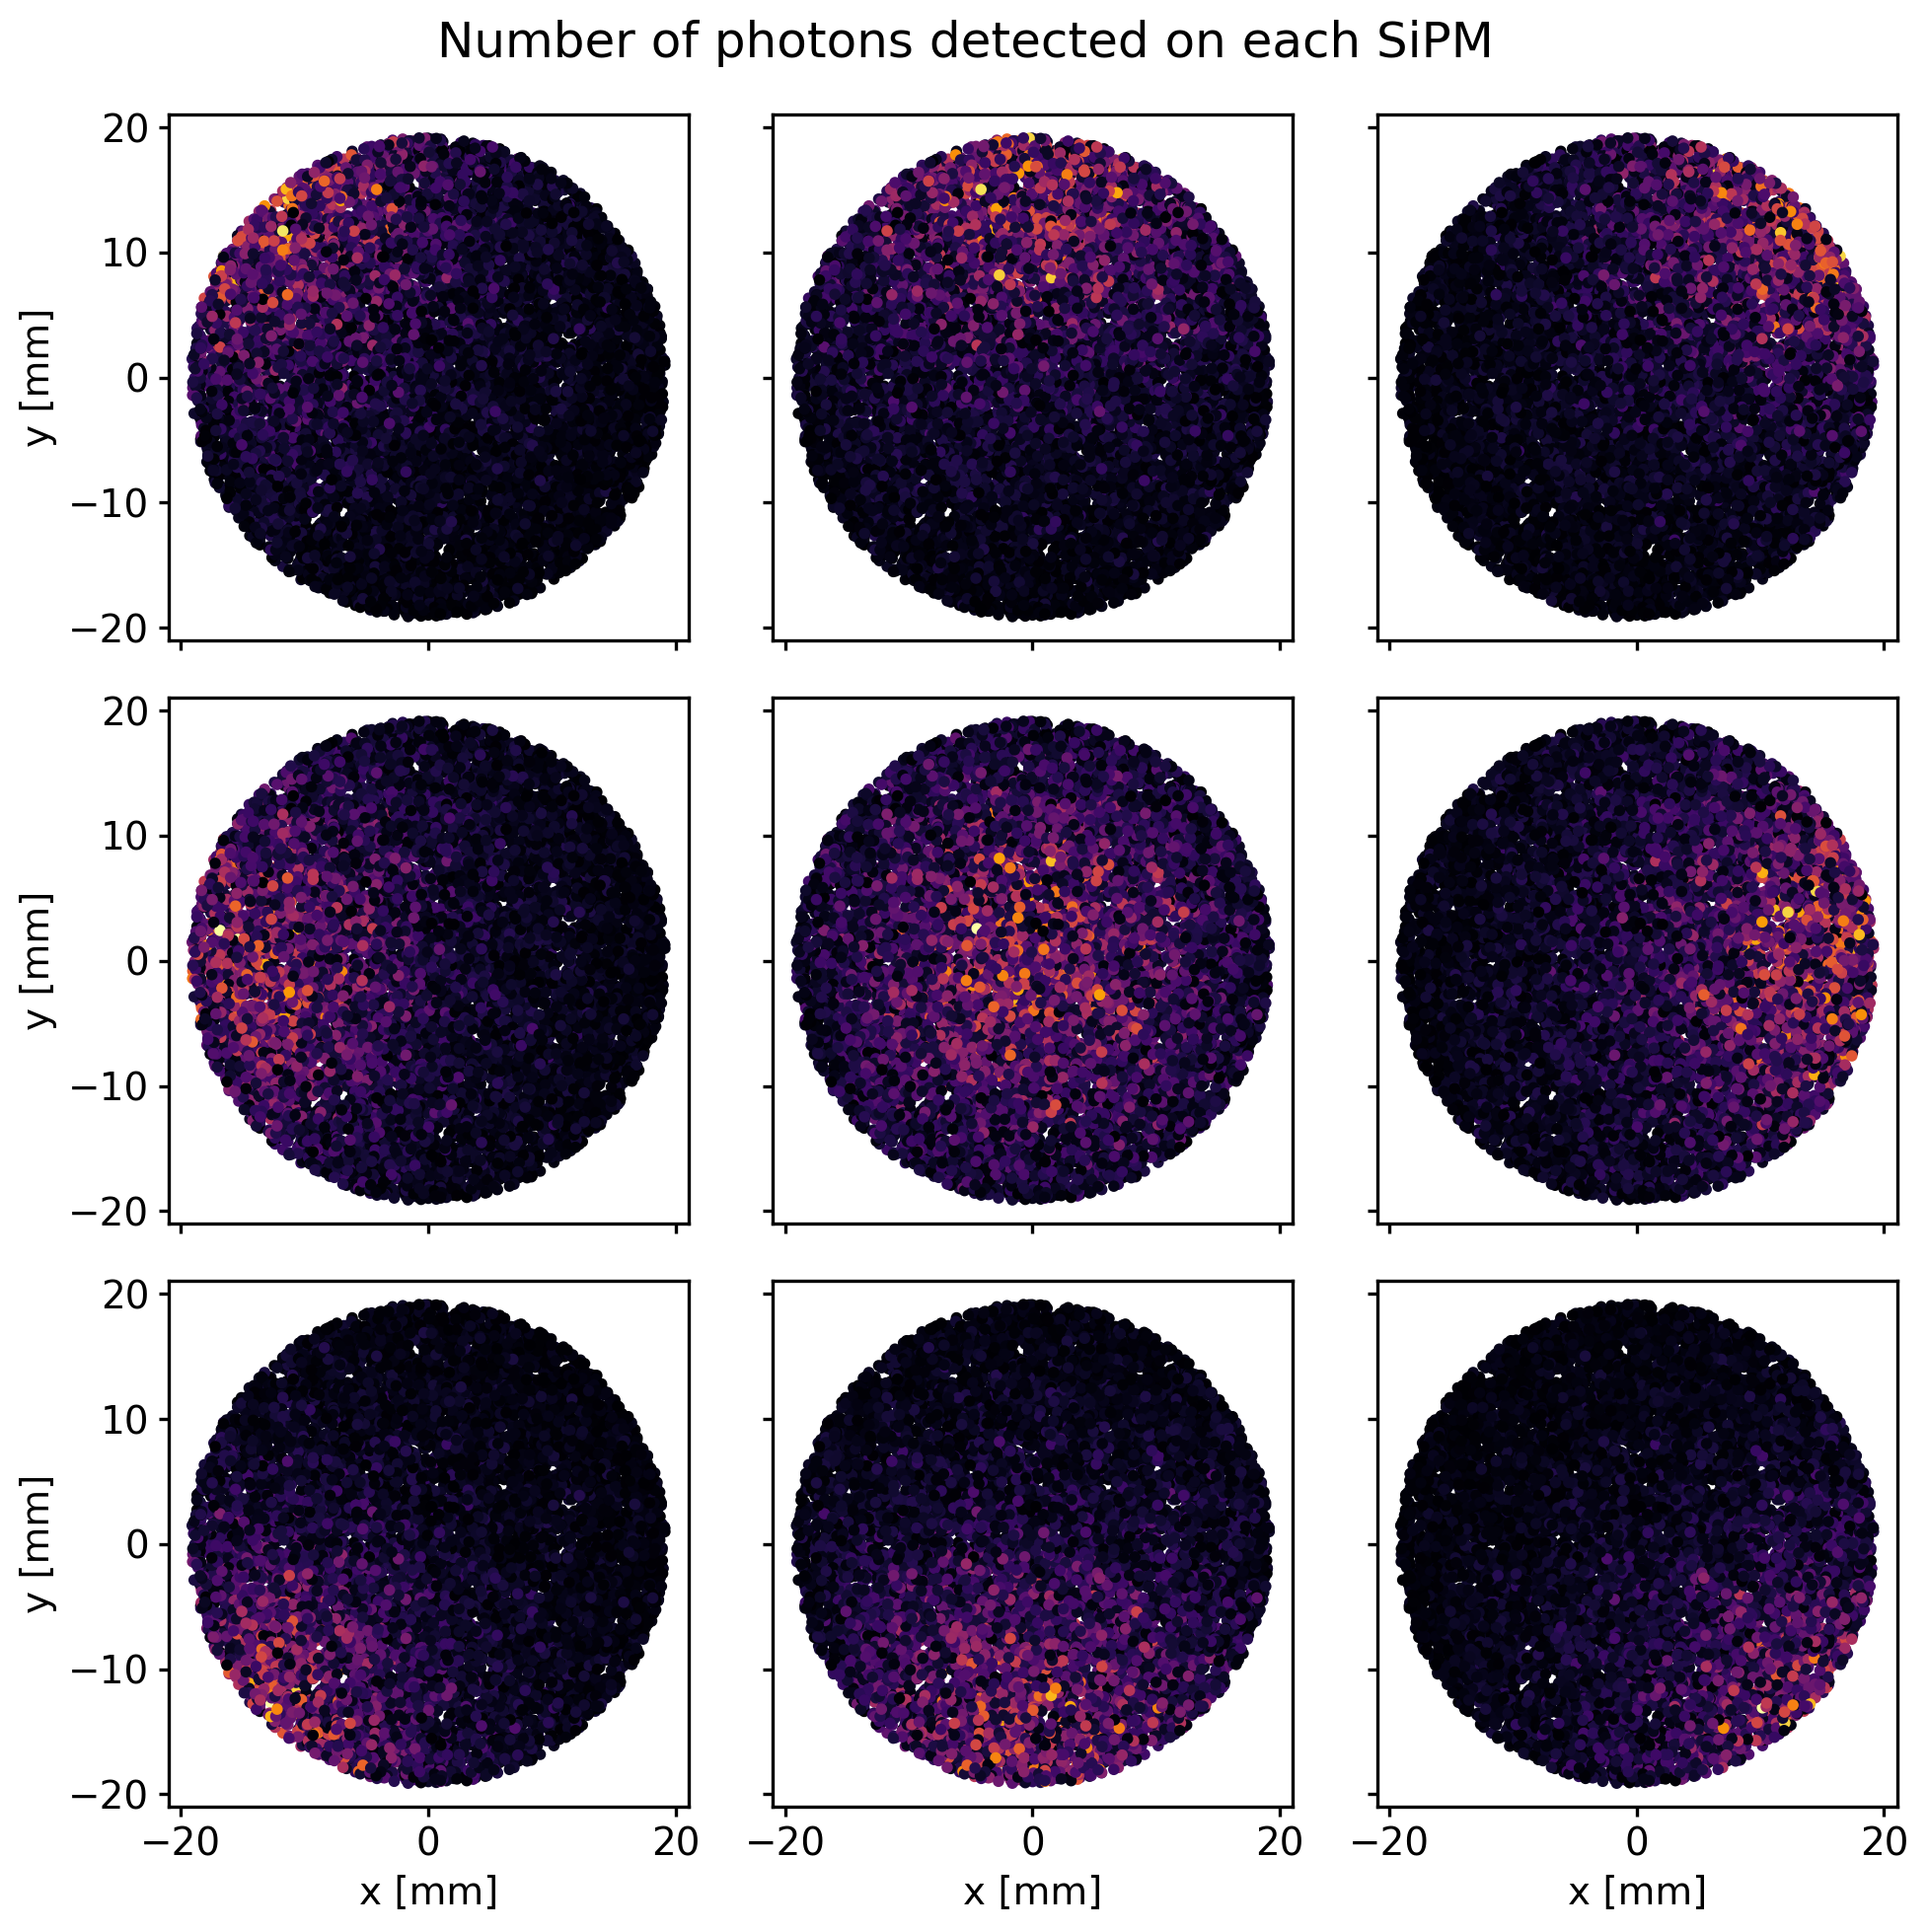

In [63]:
num_cols = 2 if pmts else 3

fig, ax = plt.subplots(num_cols, num_cols, figsize=(10, 10), sharex='col', sharey='row')
mapping = [2,3,1,0] if pmts else [2,1,0,5,4,3,8,7,6]

for i in range(num_cols):
    for j in range(num_cols):
        ax[i,j].scatter(mc_truth_pos[0], mc_truth_pos[1], \
                        c=ss_n_detected[:,mapping[num_cols*i + j]], \
                        cmap='inferno', s=10)
        if i == num_cols - 1:
            ax[i,j].set_xlabel('x [mm]')
        if j == 0:
            ax[i,j].set_ylabel('y [mm]')

fig.suptitle('Number of photons detected on each ' + sensors[:-1])
if save_figures:
    fig.savefig('/home/clarke/figures/num_photons_by_' + sensors[:-1] + '.png')
plt.tight_layout()
plt.show()

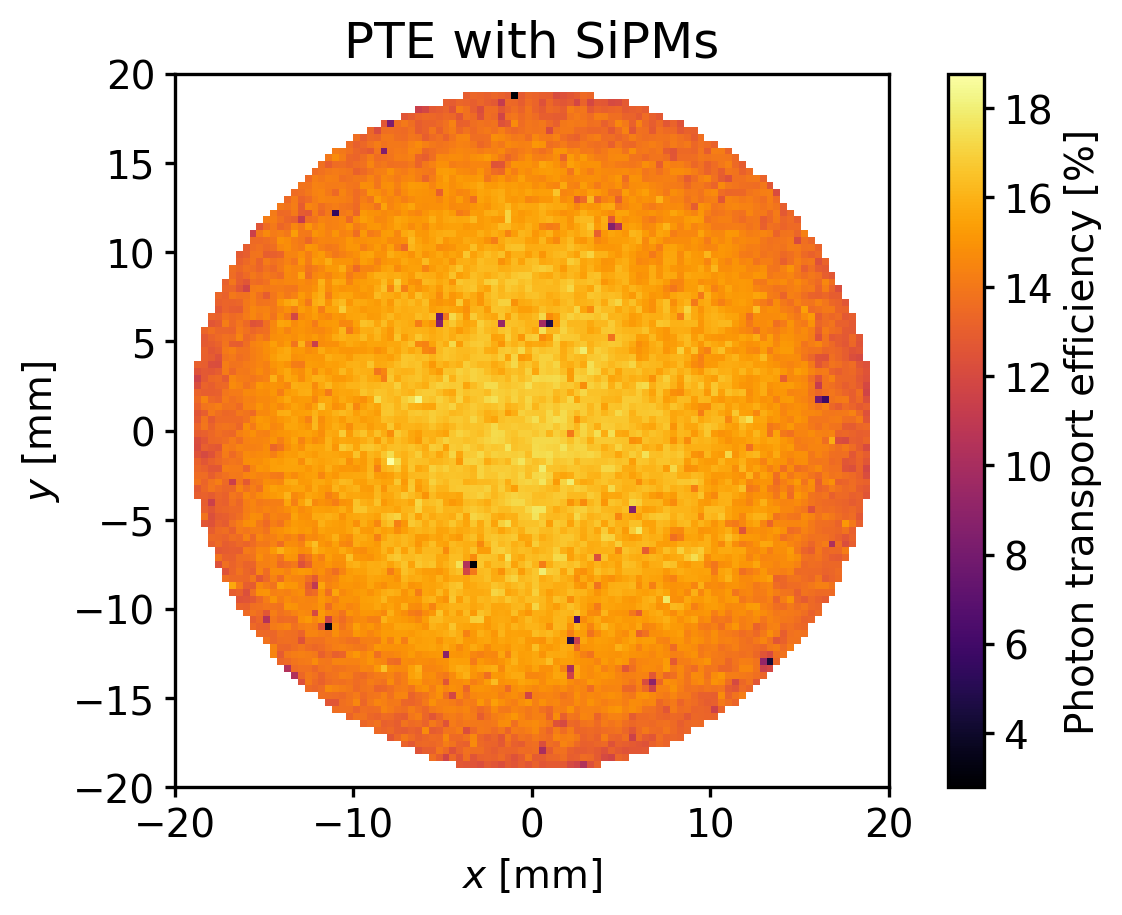

In [64]:
xi = np.linspace(np.amin(ss_mc_truth_pos[:,0]), np.amax(ss_mc_truth_pos[:,0]), 100)
yi = np.linspace(np.amin(ss_mc_truth_pos[:,1]), np.amax(ss_mc_truth_pos[:,1]), 100)
xi, yi = np.meshgrid(xi, yi)
zi = griddata((ss_mc_truth_pos[:,0], ss_mc_truth_pos[:,1]), 100*ss_pte, (xi, yi), method='linear')

fig, ax = plt.subplots()
mesh = ax.pcolormesh(xi, yi, zi, cmap='inferno')
ax.set_aspect('equal')
ax.set_xlim([-20, 20])
ax.set_ylim([-20, 20])
ax.set_xlabel('$x$ [mm]')
ax.set_ylabel('$y$ [mm]')
cbar = fig.colorbar(mesh)
cbar.set_label('Photon transport efficiency [%]')
ax.set_title('PTE with ' + sensors)
if save_figures:
    fig.savefig('/home/clarke/figures/pte_map_' + sensors[:-1] + '.png')

In [65]:
r = 13.208 + 1*6.451
s = 19.35

angle = np.arctan(2*r/s)
2*np.cos(angle)*2*angle/4./np.pi

0.15650072663822162

In [66]:
mc_truth_pos = []
mc_truth_pos_2 = []
detected = []

with h5py.File('chroma-lxe/s2_sim_test2_' + sensors + '_ms.h5', 'r') as f:
    print(f.keys())
    for key in f.keys():
        if '_detected' in key:
            detected.append(f[key][()])
        elif key=='posX':
            mc_truth_pos.append(f[key][()])
        elif key=='posY':
            mc_truth_pos.append(f[key][()])
        elif key=='posZ':
            mc_truth_pos.append(f[key][()])
        elif key=='posX_2':
            mc_truth_pos_2.append(f[key][()])
        elif key=='posY_2':
            mc_truth_pos_2.append(f[key][()])
        elif key=='posZ_2':
            mc_truth_pos_2.append(f[key][()])

ms_mc_truth_pos = np.array(mc_truth_pos).swapaxes(0, 1)
ms_mc_truth_pos_2 = np.array(mc_truth_pos_2).swapaxes(0, 1)
ms_n_detected = np.random.binomial(np.array(detected).swapaxes(0, 1).astype(int), pmt_qe)

def spatial_sep(pos, pos2):
    """Get the distance between two points in a MS event
    """
    return np.sqrt(np.sum(((pos - pos2)**2)[:,:2], axis=1))

seps = spatial_sep(ms_mc_truth_pos, ms_mc_truth_pos_2)

<KeysViewHDF5 ['ch0_detected', 'ch0_pte', 'ch1_detected', 'ch1_pte', 'ch2_detected', 'ch2_pte', 'ch3_detected', 'ch3_pte', 'ch4_detected', 'ch4_pte', 'ch5_detected', 'ch5_pte', 'ch6_detected', 'ch6_pte', 'ch7_detected', 'ch7_pte', 'ch8_detected', 'ch8_pte', 'detected', 'n', 'posX', 'posX_2', 'posY', 'posY_2', 'posZ', 'posZ_2', 'pte', 'time_spent']>


(array([ 58., 142., 227., 278., 327., 325., 331., 310., 326., 285., 320.,
        264., 254., 273., 267., 243., 224., 251., 238., 195., 209., 243.,
        207., 166., 201., 207., 163., 179., 167., 167., 141., 148., 123.,
        121., 112., 123., 113., 104., 117., 104., 109., 106.,  68.,  70.,
         75.,  65.,  51.,  59.,  46.,  39.,  40.,  34.,  43.,  38.,  36.,
         35.,  25.,  20.,  20.,  21.,  30.,  23.,  17.,  22.,   9.,  12.,
         13.,  13.,  13.,   7.,   8.,  10.,   7.,   9.,   2.,   4.,  12.,
          8.,   5.,   7.,   4.,   5.,   3.,   1.,   4.,   2.,   2.,   4.,
          0.,   1.,   1.,   0.,   2.,   1.,   0.,   0.,   1.,   0.,   0.,
          1.]),
 array([   0.  ,   11.74,   23.48,   35.22,   46.96,   58.7 ,   70.44,
          82.18,   93.92,  105.66,  117.4 ,  129.14,  140.88,  152.62,
         164.36,  176.1 ,  187.84,  199.58,  211.32,  223.06,  234.8 ,
         246.54,  258.28,  270.02,  281.76,  293.5 ,  305.24,  316.98,
         328.72,  340.46,  352.2 ,

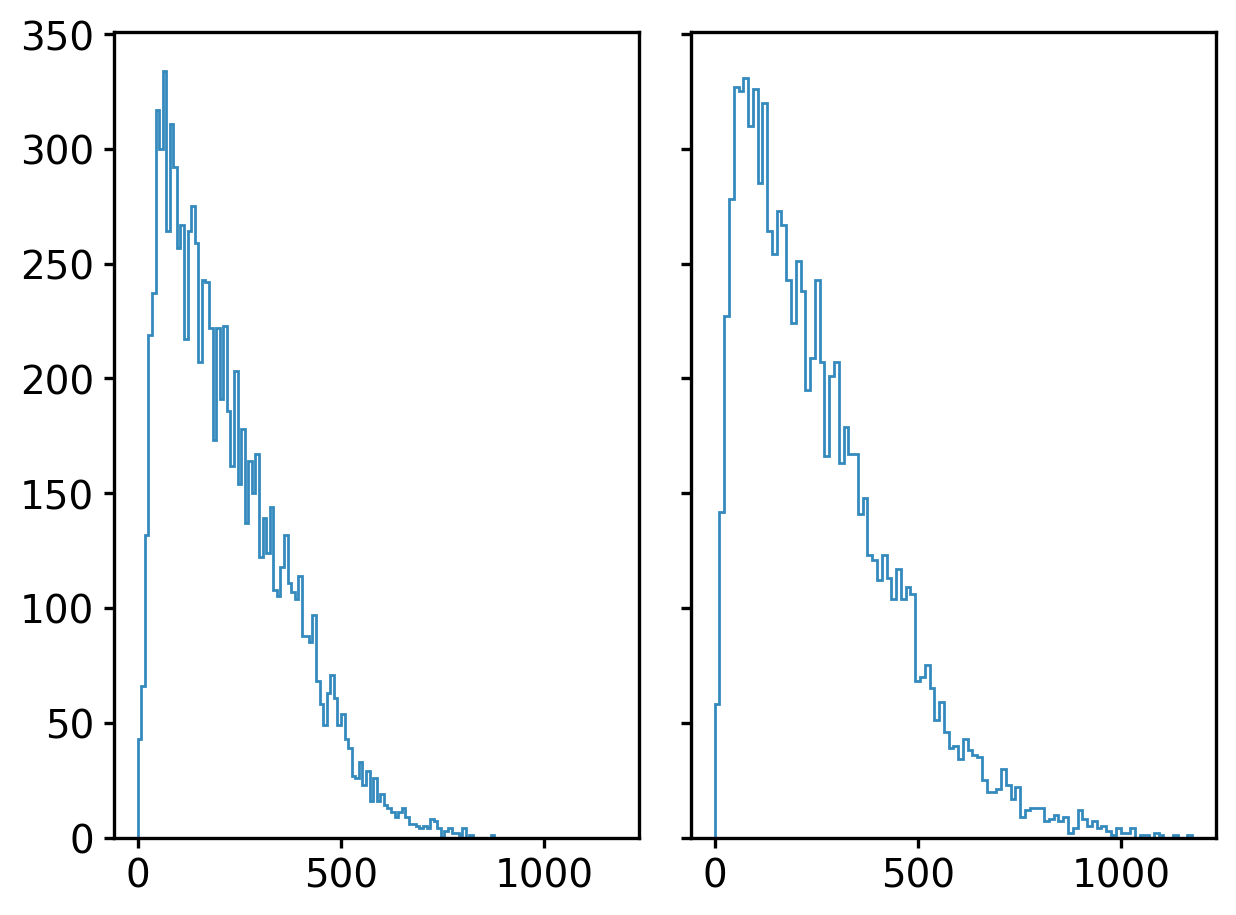

In [92]:
fig, ax = plt.subplots(1, 2, sharex=True, sharey=True)
ax[0].hist(np.sum(ss_n_detected, axis=1), histtype='step', bins=100)
ax[1].hist(np.sum(ms_n_detected, axis=1), histtype='step', bins=100)

In [87]:
n_detected = np.concatenate((ss_n_detected, ms_n_detected), axis=0)
# remove absolute energy scale and only use relative counts between sensors
# n_detected = n_detected[np.sum(n_detected, axis=1) > 0]
# n_detected = n_detected/np.sum(n_detected, axis=1, keepdims=True)
ss_truth = np.ones(ss_n_detected.shape[0])
ms_truth = np.zeros(ms_n_detected.shape[0])
truth = np.concatenate((ss_truth, ms_truth), axis=0)
seps_both = np.concatenate((np.zeros(len(ss_n_detected)), seps))

# Generate a random permutation
permutation = np.random.permutation(n_detected.shape[0])

# Apply the permutation to both arrays
n_detected_shuffled = n_detected[permutation]
truth_shuffled = truth[permutation]
seps_shuffled = seps_both[permutation]

In [88]:
if pmts:
    # Define the model
    model = keras.Sequential([
        keras.layers.Dense(64, activation='relu', input_shape=(4,)),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
    ])

    # Compile the model
    model.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])

    # Print model summary
    model.summary()
else:
    # Define the model
    model = keras.Sequential([
        keras.layers.Dense(128, activation='relu', input_shape=(9,)),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
    ])

    # Compile the model
    model.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])

    # Print model summary
    model.summary()

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_45 (Dense)            (None, 128)               1280      
                                                                 
 dense_46 (Dense)            (None, 64)                8256      
                                                                 
 dense_47 (Dense)            (None, 32)                2080      
                                                                 
 dense_48 (Dense)            (None, 16)                528       
                                                                 
 dense_49 (Dense)            (None, 1)                 17        
                                                                 


Total params: 12161 (47.50 KB)
Trainable params: 12161 (47.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Epoch 1/50
98/98 [==============================] - 1s 3ms/step - loss: 0.7426 - accuracy: 0.5120 - val_loss: 0.6969 - val_accuracy: 0.5355
Epoch 2/50
98/98 [==============================] - 0s 2ms/step - loss: 0.6977 - accuracy: 0.5322 - val_loss: 0.6911 - val_accuracy: 0.5350
Epoch 3/50
98/98 [==============================] - 0s 2ms/step - loss: 0.6920 - accuracy: 0.5451 - val_loss: 0.7032 - val_accuracy: 0.5261
Epoch 4/50
98/98 [==============================] - 0s 2ms/step - loss: 0.6886 - accuracy: 0.5488 - val_loss: 0.6854 - val_accuracy: 0.5474
Epoch 5/50
98/98 [==============================] - 0s 2ms/step - loss: 0.6863 - accuracy: 0.5481 - val_loss: 0.7024 - val_accuracy: 0.5361
Epoch 6/50
98/98 [==============================] - 0s 2ms/step - loss: 0.6853 - accuracy: 0.5516 - val_loss: 0.6860 - val_accuracy: 0.5465
Epoch 7/50
98/98 [==============================] - 0s 2ms/step - loss: 0.6830 - accuracy: 0.5627 - val_loss: 0.6857 - val_accuracy: 0.5396
Epoch 8/50
98/98 [==

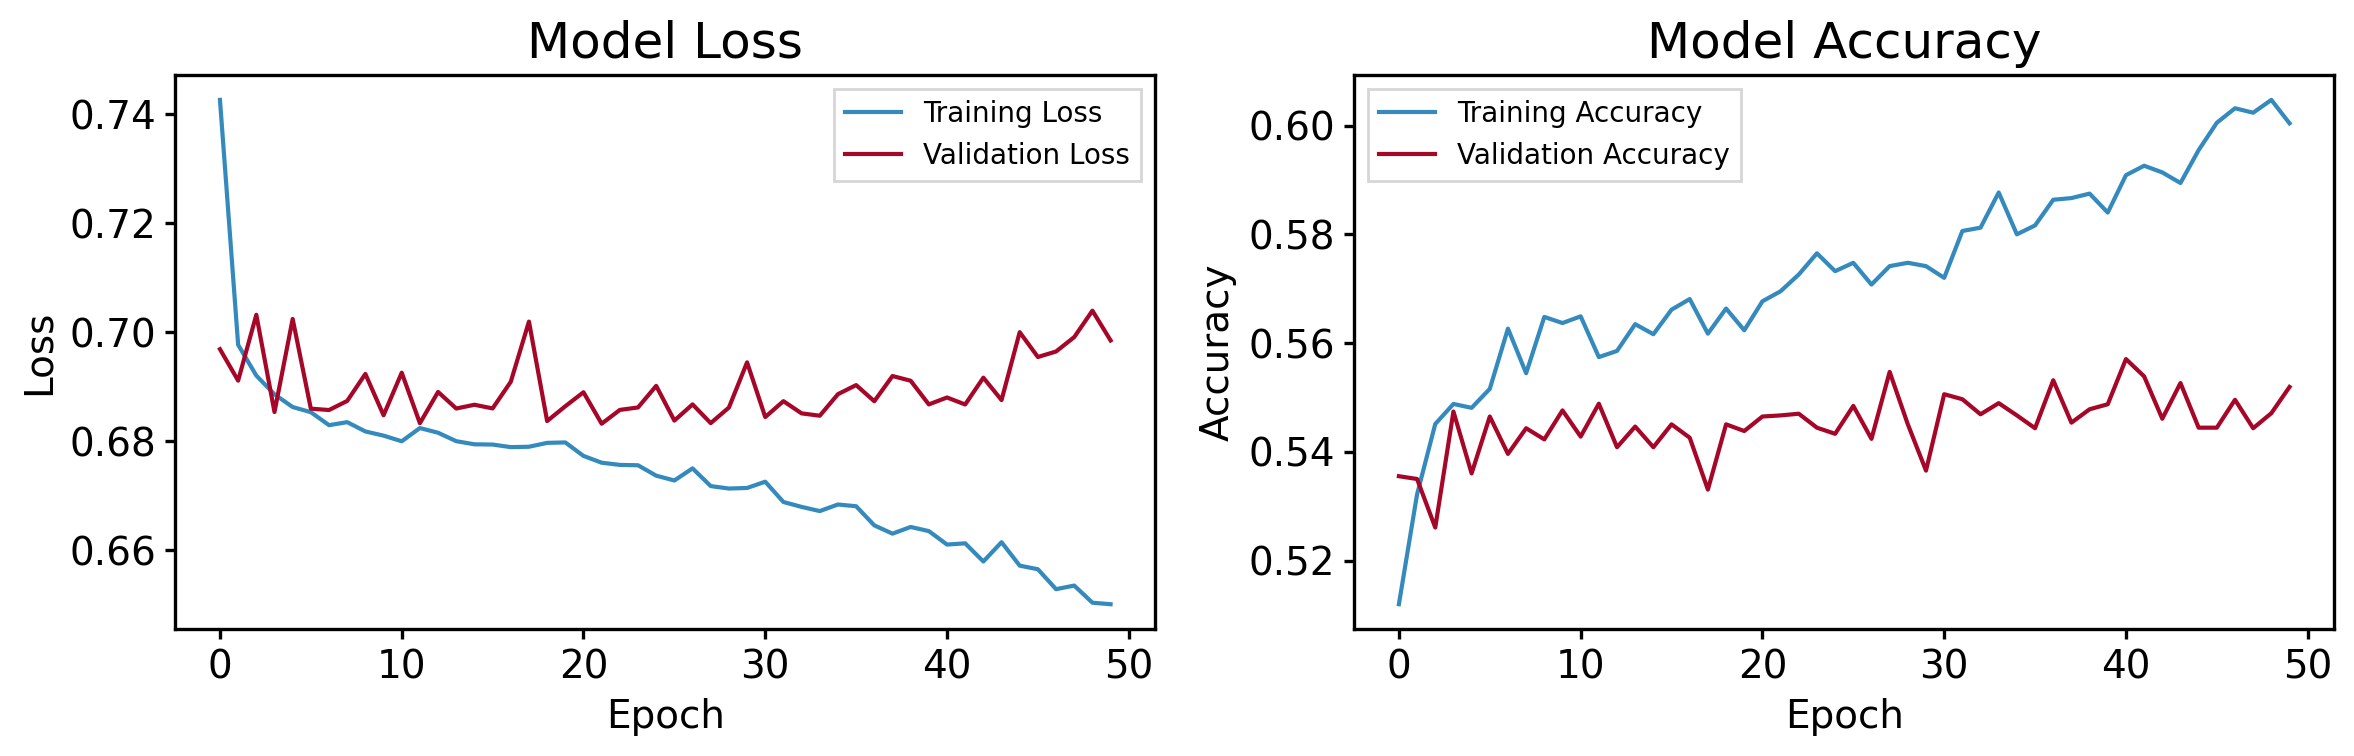

In [89]:
# Split the data into training and validation sets
split_index = len(n_detected_shuffled) // 2
X_train, X_val = n_detected_shuffled[:split_index], n_detected_shuffled[split_index:]
y_train, y_val = truth_shuffled[:split_index], truth_shuffled[split_index:]
seps_train, seps_val = seps_shuffled[:split_index], seps_shuffled[split_index:]

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=100,
    validation_data=(X_val, y_val),
    verbose=1
)

# Evaluate the model on the validation set
val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

if save_figures:
    plt.savefig('/home/clarke/figures/training' + sensors + '.png')

plt.tight_layout()
plt.show()

Youden optimal cut keeps 63.5% of signal events and removes 46.9% of background events.


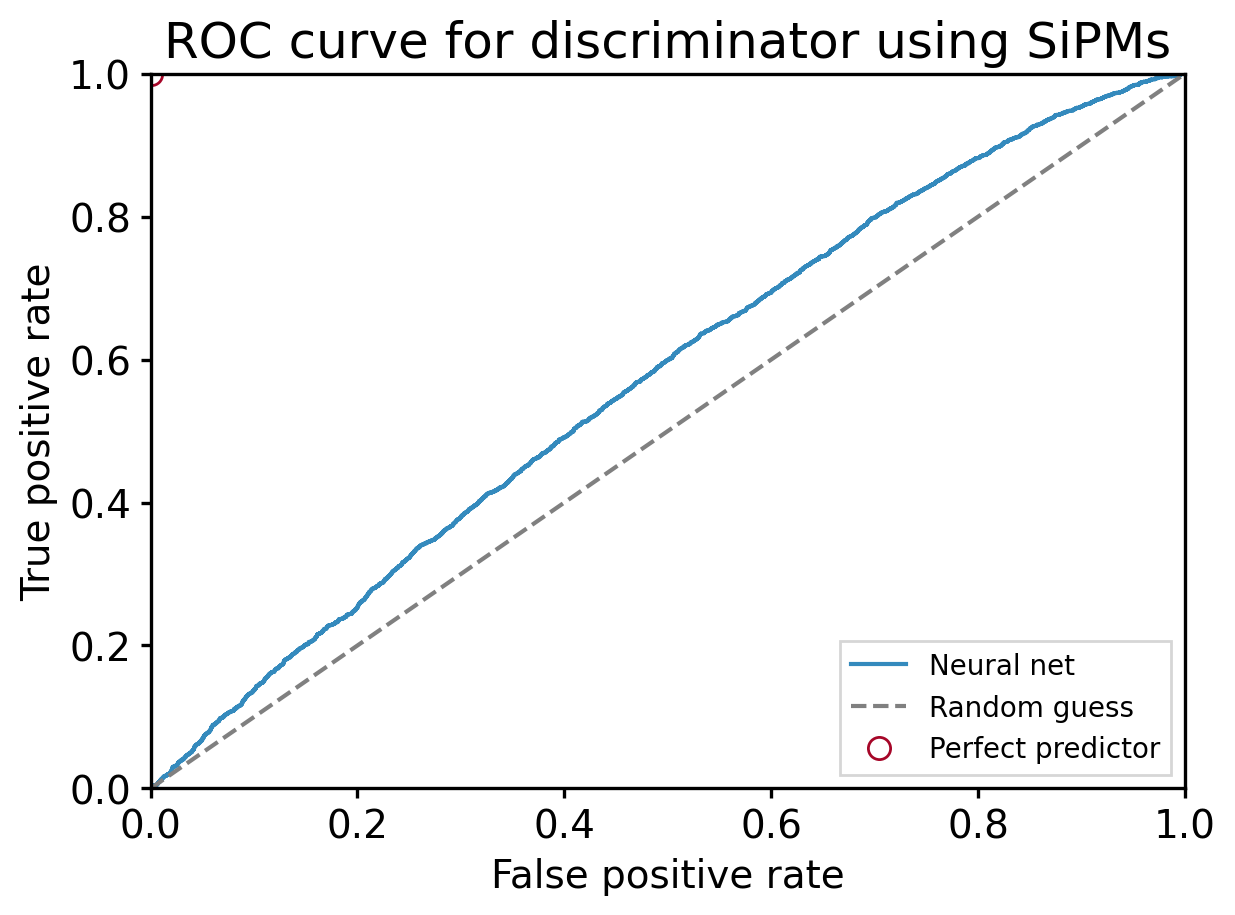

In [90]:
y_pred = np.array(np.array(model(X_val))[:,0])
y_true = np.copy(y_val)

sorted_indices = np.argsort(-y_pred)
y_true_sorted = y_true[sorted_indices]
y_pred_sorted = y_pred[sorted_indices]

P = np.sum(y_true)
N = len(y_true) - P

tpr = np.cumsum(y_true_sorted)/P
fpr = np.cumsum(1 - y_true_sorted)/N

youden = tpr - fpr - 1
opt_ind = np.argmax(youden)

print('Youden optimal cut keeps {:.1f}% of signal events and removes {:.1f}% of background events.'\
      .format(100*tpr[opt_ind], 100*(1. - fpr[opt_ind])))

fig, ax = plt.subplots()
ax.plot(fpr, tpr, label='Neural net')
ax.plot([0, 1], [0, 1], ls='--', color='grey', label='Random guess')
ax.plot([0], [1], marker='o', fillstyle='none', ls='none', ms=8, label='Perfect predictor')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curve for discriminator using ' + sensors)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.legend(loc='lower right')
if save_figures:
    fig.savefig('/home/clarke/figures/roc_' + sensors + '.png')

titles = ['one', 'ten', 'hundred']
qes = np.array([1e-2, 1e-1, 1e0])
if save_figures:
    try:
        title_ind = np.argwhere(qes==pmt_qe)[0][0]
        np.save('qe_' + titles[title_ind] + '_' + sensors + '.npy', np.vstack((fpr, tpr)))
    except:
        if pmt_qe==0.3:
            np.save('qe_30_' + sensors + '.npy', np.vstack((fpr, tpr)))

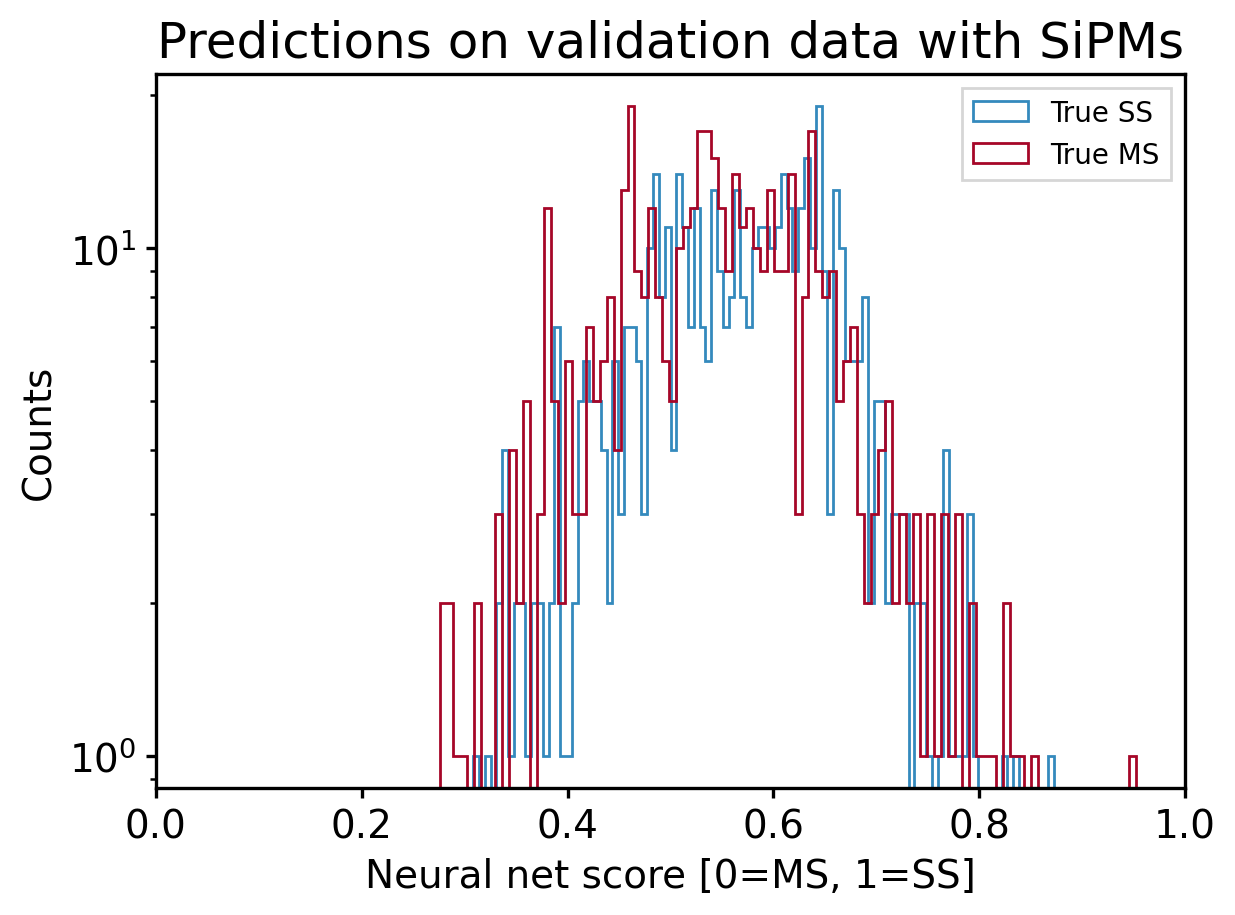

In [59]:
n_bins = 100

fig, ax = plt.subplots()
ax.hist(np.array(model(X_val)[y_val>0.5])[:,0], histtype='step', bins=n_bins, label='True SS')
ax.hist(np.array(model(X_val)[y_val<=0.5])[:,0], histtype='step', bins=n_bins, label='True MS')
ax.set_yscale('log')
ax.set_xlabel('Neural net score [0=MS, 1=SS]')
ax.set_ylabel('Counts')
ax.set_title('Predictions on validation data with ' + sensors)
ax.set_xlim([0, 1])
ax.legend()
if save_figures:
    fig.savefig('/home/clarke/figures/pdfs_' + sensors + '.png')

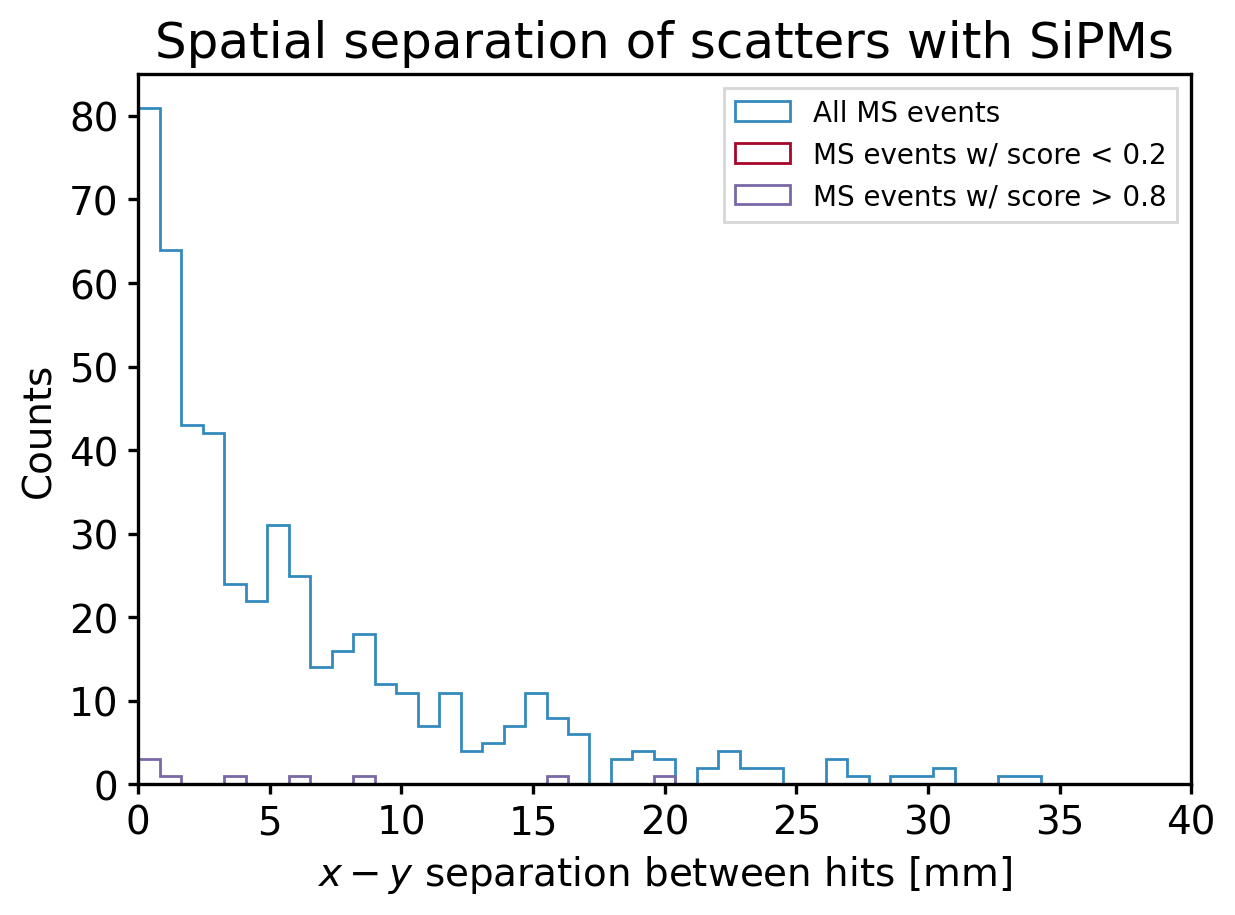

In [60]:
bins = np.linspace(0, 40, 50)

fig, ax = plt.subplots()
ax.hist(seps_val[y_val<0.5], histtype='step', label='All MS events', 
        density=False, bins=bins)
ax.hist(seps_val[(y_val<0.5) & (y_pred<0.2)], histtype='step', label='MS events w/ score < 0.2', \
        density=False, bins=bins)
ax.hist(seps_val[(y_val<0.5) & (y_pred>0.8)], histtype='step', label='MS events w/ score > 0.8', \
        density=False, bins=bins)
ax.set_xlabel('$x-y$ separation between hits [mm]')
ax.set_ylabel('Counts')
ax.set_title('Spatial separation of scatters with ' + sensors)
ax.set_xlim([0, 40])
ax.legend()
if save_figures:
    fig.savefig('/home/clarke/figures/by_separation_' + sensors + '.png')

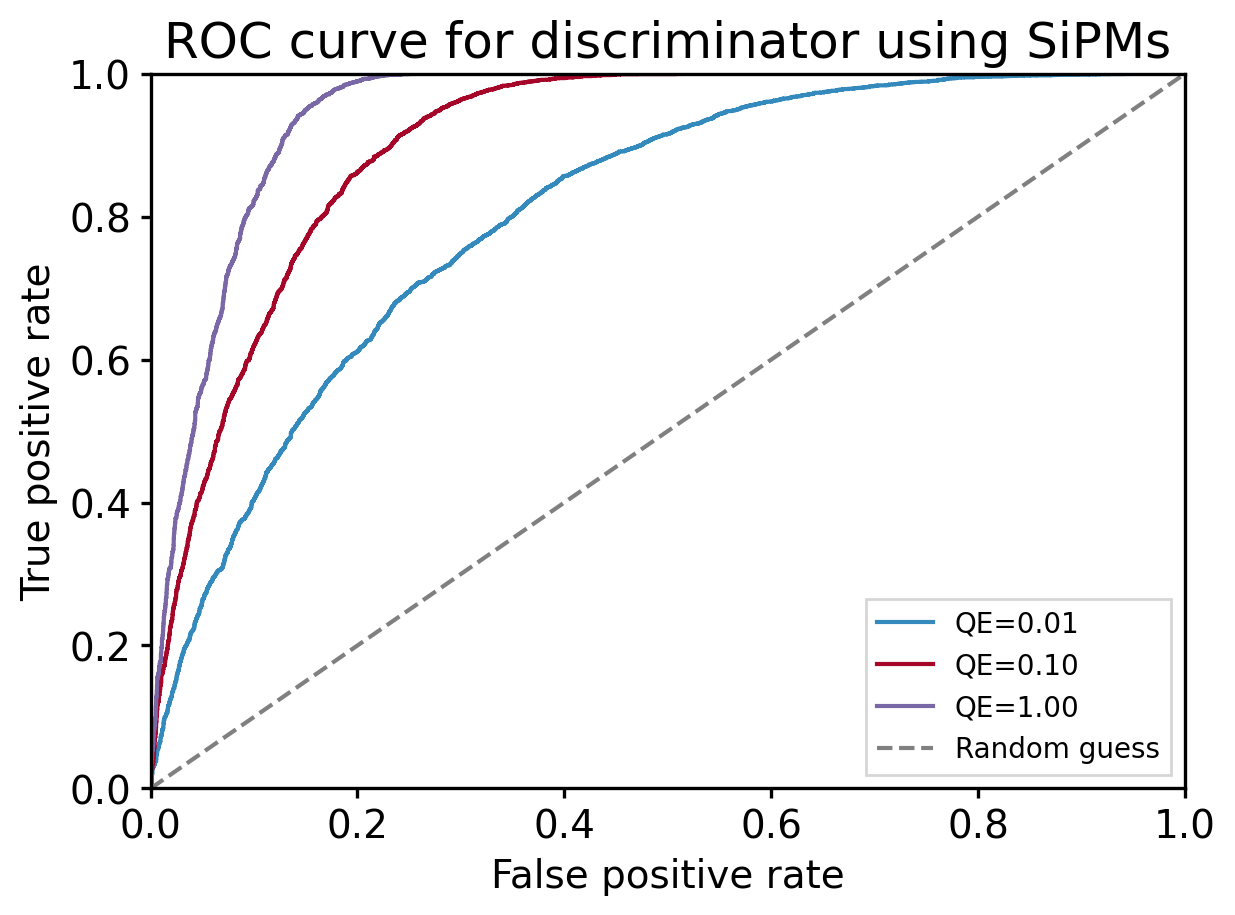

In [26]:
fig, ax = plt.subplots()
for i,title in enumerate(titles):
    fpr, tpr = np.load('qe_' + title + '_' + sensors + '.npy')
    ax.plot(fpr, tpr, label='QE={:.2f}'.format(qes[i]))
ax.plot([0, 1], [0, 1], ls='--', color='grey', label='Random guess')
#ax.plot([0], [1], marker='o', ls='none', ms=8, label='Perfect predictor')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curve for discriminator using ' + sensors)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.legend(loc='lower right')
if save_figures:
    fig.savefig('/home/clarke/figures/roc_comparison_' + sensors + '.png')

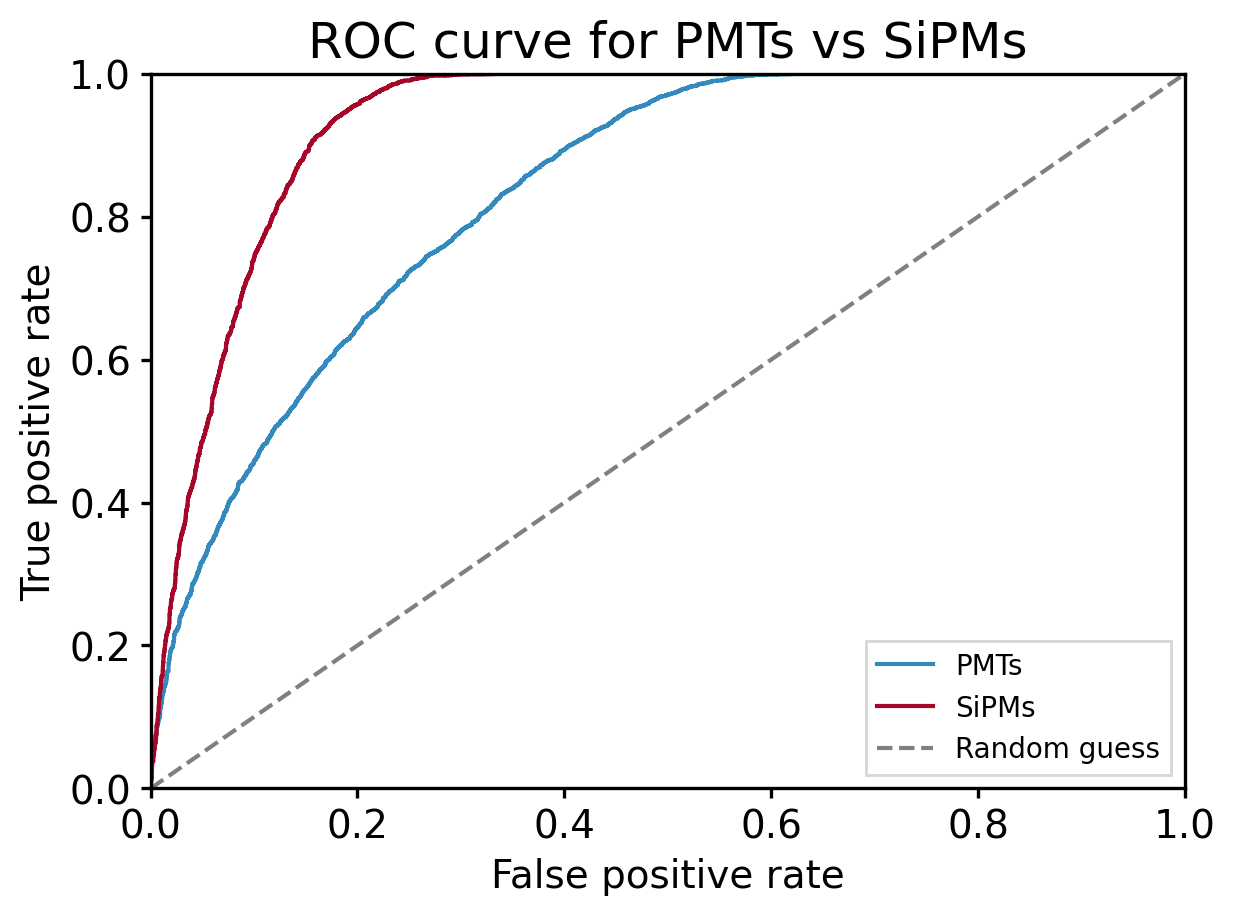

In [129]:
fig, ax = plt.subplots()
sensor_types = ['PMTs', 'SiPMs']
for i,title in enumerate(sensor_types):
    fpr, tpr = np.load('qe_30_' + sensor_types[i] + '.npy')
    ax.plot(fpr, tpr, label=sensor_types[i])
ax.plot([0, 1], [0, 1], ls='--', color='grey', label='Random guess')
#ax.plot([0], [1], marker='o', ls='none', ms=8, label='Perfect predictor')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curve for PMTs vs SiPMs')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.legend(loc='lower right')
if save_figures:
    fig.savefig('/home/clarke/figures/roc_comparison_sensors.png')